# 7. The caught/cot merger

Does a speaker pronounce **caught** and **cot** the same way?

It is one of the best-studied variables in North American English. Speakers in
Eastern New England, Western Pennsylvania, and most of Canada and the West merge
them; much of the South, the Inland North, and the Mid-Atlantic keep them apart.
The distinction lives in the vowel's **first two formants** — F1 (roughly, how
open the mouth is) and F2 (how far forward the tongue is).

This notebook measures F1 and F2 for one speaker at a time, starting from the
turn-level acoustics and going back to the source audio for the rest.

## 7.1 The acoustics stored per turn

Each turn carries six summary numbers:


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))     # prefer the source tree
sys.path.insert(0, os.path.dirname(os.path.abspath("_viz.py")))

import sporc
if sporc.__version__ < "1.0":
    raise RuntimeError(
        f"This notebook needs sporc >= 1.0 but imported {sporc.__version__} from "
        f"{os.path.dirname(sporc.__file__)}.\n"
        "PyPI's latest release is 0.2.0, which has a different API, so "
        "`pip install sporc` gets you the wrong one. Install this checkout:\n"
        "    pip install -e /path/to/sporc"
    )

from _viz import apply_style, finish, PALETTE, INK, INK_SECONDARY, INK_MUTED
apply_style()
# Report the location relative to here, so the printed output does not embed
# whoever's home directory this happened to be built in.
print("sporc", sporc.__version__, "from",
      os.path.relpath(os.path.dirname(sporc.__file__)))


sporc 1.1.0 from ../../sporc


In [2]:
from sporc import SPORCDataset

# Built by scripts/make_subset.py; see examples/notebooks/README.md. Kept
# relative so nothing machine-specific leaks into the logged path.
SUBSET = "../../subsets/tutorial"
sporc = SPORCDataset(parquet_dir=SUBSET, load_audio_features=True)
print(sporc)  # load_audio_features=True: this notebook needs the MFCCs


INFO:sporc.dataset:Initializing Parquet backend from ../../subsets/tutorial


INFO:sporc.parquet_backend:Loading indexes from cache ../../subsets/tutorial/metadata/_index_cache.pkl


INFO:sporc.parquet_backend:ParquetBackend loaded from cache in 0.06s  (403 podcasts, 2,967 episodes)


SPORCDataset(parquet, 403 podcasts, 2967 episodes)


In [3]:
ep = next(e for e in sporc.iterate_episodes() if e.has_turn_data)
turn = next(t for t in ep.turns if t.get_audio_features())

print("Turn-level acoustic features:\n")
for k, v in turn.get_audio_features().items():
    print(f"  {k:42s} {v:.3f}")

print(f"\n...covering {turn.duration:.1f} seconds and {turn.word_count} words.")


INFO:sporc.parquet_backend:Loading episode DataFrame from feather cache


INFO:sporc.parquet_backend:Loading podcast DataFrame from feather cache


Turn-level acoustic features:

  mfcc1_sma3_mean                            16.285
  mfcc2_sma3_mean                            6.663
  mfcc3_sma3_mean                            20.412
  mfcc4_sma3_mean                            4.300
  f0_semitone_from_27_5hz_sma3nz_mean        14.589
  f1_frequency_sma3nz_mean                   693.739
  mfcc1_sma3_stdev                           9.090
  mfcc2_sma3_stdev                           6.376
  mfcc3_sma3_stdev                           8.641
  mfcc4_sma3_stdev                           6.637
  f0_semitone_from_27_5hz_sma3nz_stdev       9.062
  f1_frequency_sma3nz_stdev                  125.277

...covering 20.9 seconds and 57 words.


These are turn-level means: averaged over many words and phonemes, silence
included. They carry F1 but not F2, and nothing marks when any individual word
was said. A vowel lasts ~100 ms, so for a per-vowel measurement we need
timings at the phone level and both formants.

Note `estimate_word_audio()` is not that. It interpolates by *character offset*,
assuming every letter takes equally long to say, so its error in a 60-second turn
runs to seconds. Use it to find roughly where in an episode a word falls; it is
deprecated for phonetic work.

## 7.2 From turn to source audio

Every turn carries an `mp3_url` and its own `start_time`/`end_time`, which is
enough to go back to the source audio and align it properly:

```
turn text + turn audio  ->  forced alignment  ->  word and phone timings
phone timings + audio   ->  Praat             ->  F1/F2 at the vowel
```

`sporc.phonetics` implements that chain (`pip install sporc[phonetics]`, plus
ffmpeg). It fetches **only the turn**, via an HTTP range request — a 10-second
turn costs ~1–2 s and a few hundred KB, not a 100 MB episode download.

That fetch is the cheap half. Aligning the turn is what actually costs, and it
scales with the turn's length rather than the word's — see 7.5, where that
governs how the tokens are collected.


In [4]:
from sporc.phonetics import (fetch_turn_audio, align_turn, measure_formants,
                             pronounce, stressed_vowel_index, lexical_set,
                             THOUGHT_WORDS, LOT_WORDS)

print(f"THOUGHT set (the 'caught' class): {len(THOUGHT_WORDS)} words")
print(f"LOT set     (the 'cot' class)   : {len(LOT_WORDS)} words")


THOUGHT set (the 'caught' class): 72 words
LOT set     (the 'cot' class)   : 70 words


## 7.3 Lexical sets: membership comes from the word

Lexical-set membership must come from the **word**, not from a pronunciation
dictionary. CMUdict lists *caught* as `K AA1 T` — the **LOT** vowel — because the
merger is already baked into the dictionary.

Classify tokens by their dictionary vowel and you label *caught* as LOT, which
answers the research question before measuring anything. Wells' lexical sets are
fixed by the word's history; whether a speaker merges them is what we're here to
find out.


In [5]:
for w in ["caught", "cot", "talk", "across", "thought", "lot"]:
    ph = pronounce(w)
    vi = stressed_vowel_index(ph)
    print(f"  {w:8s} cmudict={str(ph):32s} vowel={ph[vi]:5s} -> set={lexical_set(w)}")

print("\n  ^ 'caught' is K AA1 T in cmudict (already merged), yet it is a")
print("    THOUGHT word. The set comes from the word, never from the vowel.")


  caught   cmudict=['K', 'AA1', 'T']                vowel=AA1   -> set=THOUGHT
  cot      cmudict=['K', 'AA1', 'T']                vowel=AA1   -> set=LOT
  talk     cmudict=['T', 'AO1', 'K']                vowel=AO1   -> set=THOUGHT
  across   cmudict=['AH0', 'K', 'R', 'AO1', 'S']    vowel=AO1   -> set=THOUGHT
  thought  cmudict=['TH', 'AO1', 'T']               vowel=AO1   -> set=THOUGHT
  lot      cmudict=['L', 'AA1', 'T']                vowel=AA1   -> set=LOT

  ^ 'caught' is K AA1 T in cmudict (already merged), yet it is a
    THOUGHT word. The set comes from the word, never from the vowel.


## 7.4 One token, end to end

Find a turn containing a target word, fetch its audio, align it, and look at
where the phones actually fall.


In [6]:
import re

TARGETS = sorted(THOUGHT_WORDS | LOT_WORDS)

def find_turns(word, limit=3):
    """Turns containing `word` as a whole word, with the mp3_url attached."""
    out = []
    for hit in sporc.search_turns(word, mode="exact", limit=limit * 20):
        if not re.search(rf"\b{re.escape(word)}\b", hit.get("turn_text", ""), re.I):
            continue                       # 'exact' is substring: 'cot' in 'cottage'
        dur = hit["end_time"] - hit["start_time"]
        if not (1.5 < dur < 25):
            continue                       # short turns align more tightly
        epi = sporc._parquet_backend.get_episode_by_id(hit["episode_id"])
        if not epi:
            continue
        hit = dict(hit, mp3_url=epi.get("mp3_url"))
        out.append(hit)
        if len(out) >= limit:
            break
    return out

demo = None
for w in ["talk", "not", "got", "lot", "thought", "long"]:
    hits = find_turns(w, limit=1)
    if hits:
        demo, demo_word = hits[0], w
        break

print(f"word : {demo_word!r}  ({lexical_set(demo_word)} set)")
print(f"turn : {demo['start_time']:.1f}s-{demo['end_time']:.1f}s of episode {demo['episode_id'][:12]}")
print(f"text : {demo['turn_text'][:100]!r}")
print(f"audio: {demo['mp3_url'][:70]}...")


word : 'talk'  (THOUGHT set)
turn : 164.6s-174.6s of episode a4908182dd98
text : ' Wes grateful to be here and you know thank you for for having me on here to talk all things busines'
audio: https://anchor.fm/s/68eec9d4/podcast/play/39885821/https%3A%2F%2Fd3ctx...


In [7]:
audio, sr = fetch_turn_audio(demo)          # range-fetches just this turn
print(f"fetched {len(audio)/sr:.1f}s of audio @ {sr} Hz "
      f"({audio.nbytes/1e6:.2f} MB in memory)")

words = align_turn(demo, audio=audio, sample_rate=sr, level="word")
hit = next(w for w in words if w.word.lower() == demo_word)
print(f"\n'{hit.word}' aligned to {hit.start:.3f}s-{hit.end:.3f}s "
      f"({hit.duration*1000:.0f} ms)")
print("\nneighbouring words:")
i = words.index(hit)
for w in words[max(0, i-3):i+4]:
    mark = "  <--" if w is hit else ""
    print(f"   {w.start:6.3f}-{w.end:6.3f}  {w.word:<14s}{mark}")


fetched 10.6s of audio @ 16000 Hz (0.68 MB in memory)



'TALK' aligned to 4.589s-4.989s (401 ms)

neighbouring words:
    3.667- 3.807  ON            
    3.807- 4.048  HERE          
    4.048- 4.589  TO            
    4.589- 4.989  TALK            <--
    4.989- 5.170  ALL           
    5.170- 5.591  THINGS        
    5.591- 6.071  BUSINESS      


### 7.4.1 Down to the phone

Word timing isn't enough — we need the *vowel*, not the word. Taking the word's
midpoint would be wrong for anything but a simple CVC: in *across* (`AH0 K R AO1
S`) the vowel of interest is the second one.

So the target word is phone-aligned against its CMUdict pronunciation, and the
**stressed** vowel is selected.


In [8]:
lo = max(0, int((hit.start - 0.05) * sr))
hi = min(len(audio), int((hit.end + 0.05) * sr))
clip = audio[lo:hi]

phones = align_turn(demo, audio=clip, sample_rate=sr, level="phone", word=demo_word)
vi = stressed_vowel_index([p.arpabet for p in phones])

print(f"phone alignment of '{demo_word}':\n")
for i, p in enumerate(phones):
    mark = "   <-- stressed vowel" if i == vi else ""
    print(f"   {p.start*1000:6.0f}-{p.end*1000:6.0f} ms  {p.phone:4s} ({p.arpabet:4s})"
          f"  {p.duration*1000:5.0f} ms{mark}")

v = phones[vi]
vals = measure_formants(clip, sr, v.start, v.end)
print(f"\nF1 = {vals['f1']:.0f} Hz   F2 = {vals['f2']:.0f} Hz"
      f"   (vowel {v.duration*1000:.0f} ms)")


INFO:httpx:HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-lv-60-espeak-cv-ft/resolve/main/vocab.json "HTTP/1.1 307 Temporary Redirect"


INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-lv-60-espeak-cv-ft/ae45363bf3413b374fecd9dc8bc1df0e24c3b7f4/vocab.json "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-lv-60-espeak-cv-ft/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"


INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-lv-60-espeak-cv-ft/ae45363bf3413b374fecd9dc8bc1df0e24c3b7f4/config.json "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-lv-60-espeak-cv-ft/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"


...

INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/facebook/wav2vec2-lv-60-espeak-cv-ft/commits/refs%2Fpr%2F4 "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-lv-60-espeak-cv-ft/resolve/refs%2Fpr%2F4/model.safetensors.index.json "HTTP/1.1 404 Not Found"


INFO:httpx:HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-lv-60-espeak-cv-ft/resolve/refs%2Fpr%2F4/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

phone alignment of 'talk':

       42-   125 ms  t    (T   )     83 ms
      125-   292 ms  ɔ    (AO1 )    167 ms   <-- stressed vowel
      292-   501 ms  k    (K   )    209 ms

F1 = 563 Hz   F2 = 872 Hz   (vowel 167 ms)


> **A caveat the module handles for you.** CTC alignment is *peaky*: the model
> emits each phone at essentially one 20 ms frame, so the raw span is a spike,
> not a boundary. Taken literally, every vowel would look ~20 ms long. The module
> derives each phone's interval from the gap to its neighbour's spike, which puts
> durations back in the 50–150 ms range you see above. Treat the boundaries as
> good to a few tens of ms — not as hand-corrected Praat segmentation.

## 7.5 Collecting tokens at scale

`find_word_tokens()` runs the whole chain over search results. Two things govern
how you call it, and both are easy to get wrong.

**The cost is alignment, not network.** Finding a word means aligning the turn's
whole text to its whole audio, and CTC runs at roughly **0.45× realtime on CPU**
— so a turn costs about half its own duration no matter how short the target
word is. Turns here are long: for a common word the median is ~64 s, the mean
~160 s, and the longest in the corpus is **3,240 s** — a 54-minute monologue,
about 24 minutes of CPU to find one word in. `max_turn_duration` (default 30 s)
is what keeps this finite; it tells you what it skipped.

**Tokens must land on the same speaker.** Lobanov normalizes *within* a speaker,
so 50 tokens spread over 50 people normalize nothing. Searching corpus-wide
scatters exactly that way. Searching **within a podcast** concentrates tokens on
its host, who does most of the talking — and because a speaker is their name,
tokens still pool across episodes and across shows for anyone who recurs.


In [9]:
from sporc.phonetics import find_word_tokens
import itertools, collections, time

# Frequent members of each set; rare words like "cot" yield too few tokens.
PROBE = ["talk", "long", "off", "across",      # THOUGHT
         "not", "got", "lot", "job"]           # LOT
PER_WORD = 4
N_PODCASTS = 2          # ~6 min each; the whole cost of this notebook

# Pick podcasts that actually carry both sets in turns short enough to align,
# from speakers the corpus could name. Cheap: metadata only, no audio.
cand = collections.Counter()
for w in PROBE:
    for h in sporc.search_turns(w, mode="exact", limit=400):
        secs = float(h.get("end_time", 0)) - float(h.get("start_time", 0))
        if 0 < secs <= 30.0 and str(h.get("speaker_name")) != "NO_INFERRED_SPEAKER":
            cand[h["podcast_id"]] += 1
targets = [p for p, _ in cand.most_common(N_PODCASTS)]
print(f"{len(cand)} podcasts carry probe words in alignable turns; "
      f"using the top {len(targets)}")

t0 = time.time()
tokens = []
for pid in targets:
    for w in PROBE:
        try:
            tokens.extend(find_word_tokens(sporc, w, limit=PER_WORD,
                                           podcast_id=pid))
        except Exception as e:
            print(f"  {w:10s} failed: {type(e).__name__}: {e}")
    print(f"  {pid}  ->  {len(tokens):3d} tokens so far "
          f"({time.time()-t0:4.0f}s)", flush=True)

print(f"\ntotal measured tokens: {len(tokens)}  in {time.time()-t0:.0f}s")
if tokens:
    print(f"~{(time.time()-t0)/max(len(tokens),1):.1f}s per token "
          f"(aligning each turn dominates; see max_turn_duration)")


19 podcasts carry probe words in alignable turns; using the top 2


INFO:sporc.phonetics:talk: skipped 4 turn(s) longer than 30s (raise max_turn_duration to include them, at ~0.45x realtime each)


INFO:sporc.phonetics:long: skipped 19 turn(s) longer than 30s (raise max_turn_duration to include them, at ~0.45x realtime each)


INFO:sporc.phonetics:off: skipped 8 turn(s) longer than 30s (raise max_turn_duration to include them, at ~0.45x realtime each)


INFO:sporc.phonetics:across: skipped 11 turn(s) longer than 30s (raise max_turn_duration to include them, at ~0.45x realtime each)


...

INFO:sporc.phonetics:got: skipped 7 turn(s) longer than 30s (raise max_turn_duration to include them, at ~0.45x realtime each)


INFO:sporc.phonetics:lot: skipped 2 turn(s) longer than 30s (raise max_turn_duration to include them, at ~0.45x realtime each)


INFO:sporc.phonetics:job: skipped 5 turn(s) longer than 30s (raise max_turn_duration to include them, at ~0.45x realtime each)


  42a0ef5631f1  ->   53 tokens so far ( 705s)



total measured tokens: 53  in 706s
~13.3s per token (aligning each turn dominates; see max_turn_duration)


In [10]:
import pandas as pd

df = pd.DataFrame([t.to_dict() for t in tokens])
df = df[df.lexical_set.notna()]
print(f"tokens with a lexical set : {len(df)}")
print(f"distinct speakers         : {df.speaker.nunique()}")
print()
print(df.groupby("lexical_set").agg(n=("f1", "size"), f1=("f1", "mean"),
                                    f2=("f2", "mean")).round(0).to_string())


tokens with a lexical set : 53
distinct speakers         : 4

              n     f1      f2
lexical_set                   
LOT          28  732.0  1689.0
THOUGHT      25  536.0  1479.0


## 7.6 Lobanov normalization

Pooling speakers is the classic sociophonetics error. Formant frequencies scale
with vocal-tract length, so raw F1/F2 differences across speakers mostly measure
**anatomy**, not phonology. A 6'4" man and a 5'0" woman producing the identical
vowel will differ by hundreds of Hz — far more than THOUGHT differs from LOT.

**Lobanov normalization** centres and scales each speaker's own vowel space
(a z-score within speaker), which makes tokens comparable across people. It is
not a nicety; without it the chart below is noise.


In [11]:
from sporc.phonetics import lobanov_normalize

# min_tokens=4 is far too low for a real claim -- a z-score over four points is
# barely a distribution. It is set here so the tutorial plots something from a
# ~12-minute fetch; put it back to 15-20 for anything you publish.
#
# What raises it is tokens *per speaker*, not tokens: more probe words per
# podcast, or more episodes of the same host. More podcasts mostly adds more
# speakers with too few tokens each. lobanov_normalize drops the corpus's
# NO_INFERRED_SPEAKER placeholder for you -- it is the most common speaker
# value here and would otherwise pass this threshold easily while pooling
# dozens of different people into one "speaker".
MIN_TOKENS = 4
norm = lobanov_normalize(df, min_tokens=MIN_TOKENS)
print(f"speakers with >= {MIN_TOKENS} tokens : {norm.speaker.nunique() if len(norm) else 0}")
print(f"tokens retained           : {len(norm)}")
if len(norm):
    print()
    print(norm.groupby("lexical_set").agg(
        n=("f1_z", "size"), f1_z=("f1_z", "mean"), f2_z=("f2_z", "mean")
    ).round(2).to_string())
else:
    print("\nNot enough tokens per speaker to normalize. Raise the limit in")
    print("find_word_tokens(), or widen PROBE, and re-run.")


INFO:sporc.phonetics:dropping 30 token(s) from unidentified speakers (NO_INFERRED_SPEAKER): they name no one, so they cannot be normalized per speaker


speakers with >= 4 tokens : 2
tokens retained           : 22

              n  f1_z  f2_z
lexical_set                
LOT          11  0.29  0.46
THOUGHT      11 -0.29 -0.46


## 7.7 The vowel space

The conventional sociophonetic plot: **F2 on x, F1 on y, both reversed**, so the
axes mirror the mouth — high/front vowels to the upper left, low/back to the
lower right.

If a speaker **merges** caught and cot, the two clouds sit on top of each other.
If they **keep them apart**, THOUGHT sits higher and backer (lower F1, lower F2)
than LOT.


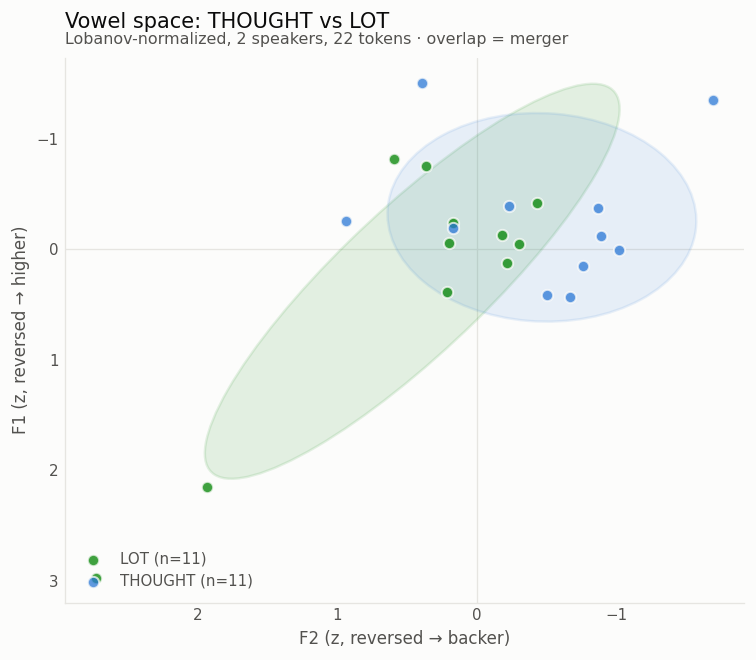

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

SET_COLOR = {"THOUGHT": PALETTE[0], "LOT": PALETTE[1]}   # 2 series: fixed slots

def ellipse(ax, x, y, color, n_std=1.5, **kw):
    """1.5-sigma covariance ellipse: where that speaker's class lives."""
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h = 2 * n_std * np.sqrt(np.maximum(vals, 1e-12))
    ax.add_patch(Ellipse((np.mean(x), np.mean(y)), w, h, angle=theta,
                         facecolor=color, alpha=0.10, edgecolor=color,
                         linewidth=1.5, **kw))

if len(norm):
    fig, ax = plt.subplots(figsize=(6.4, 5.6))
    for lset, sub in norm.groupby("lexical_set"):
        c = SET_COLOR.get(lset, INK_MUTED)
        ax.scatter(sub.f2_z, sub.f1_z, s=46, color=c, alpha=0.75,
                   edgecolor="#fcfcfb", linewidth=1.2, label=f"{lset} (n={len(sub)})",
                   zorder=3)
        ellipse(ax, sub.f2_z.values, sub.f1_z.values, c, zorder=2)

    ax.invert_xaxis(); ax.invert_yaxis()
    ax.axhline(0, color="#e6e5e1", linewidth=0.8, zorder=1)
    ax.axvline(0, color="#e6e5e1", linewidth=0.8, zorder=1)
    ax.grid(False)
    ax.legend(loc="lower left")
    finish(ax, title="Vowel space: THOUGHT vs LOT",
           subtitle=f"Lobanov-normalized, {norm.speaker.nunique()} speakers, "
                    f"{len(norm)} tokens · overlap = merger",
           xlabel="F2 (z, reversed → backer)", ylabel="F1 (z, reversed → higher)")
    plt.show()
else:
    print("Not enough normalized tokens to plot.")


## 7.8 The Pillai score

Eyeballing ellipse overlap isn't a measurement. The standard statistic is the
**Pillai score** from a MANOVA of (F1, F2) on lexical set:

* **≈ 0** → the classes are indistinguishable — *merged*
* **higher** → the classes separate — *distinct*

Reported per speaker, because merger is a property of a speaker, not of a corpus.


In [13]:
from statsmodels.multivariate.manova import MANOVA

def pillai(sub):
    if sub.lexical_set.nunique() < 2:
        return None
    if sub.groupby("lexical_set").size().min() < 3:
        return None
    try:
        m = MANOVA.from_formula("f1_z + f2_z ~ C(lexical_set)", data=sub)
        return float(m.mv_test().results["C(lexical_set)"]["stat"].iloc[1, 0])
    except Exception:
        return None

if len(norm):
    rows = []
    for sp, sub in norm.groupby("speaker"):
        p = pillai(sub)
        if p is not None:
            rows.append({"speaker": sp, "pillai": p, "n": len(sub),
                         "n_thought": int((sub.lexical_set == "THOUGHT").sum()),
                         "n_lot": int((sub.lexical_set == "LOT").sum())})
    res = pd.DataFrame(rows).sort_values("pillai")
    print(res.round(3).to_string(index=False) if len(res)
          else "No speaker has >=3 tokens of BOTH classes.")

    overall = pillai(norm)
    if overall is not None:
        print(f"\npooled across speakers (diagnostic only): {overall:.3f}")
else:
    res = pd.DataFrame()


      speaker  pillai  n  n_thought  n_lot
 Chris Holmes   0.257 14          8      6
Lisa Phillips   0.305  8          3      5

pooled across speakers (diagnostic only): 0.238


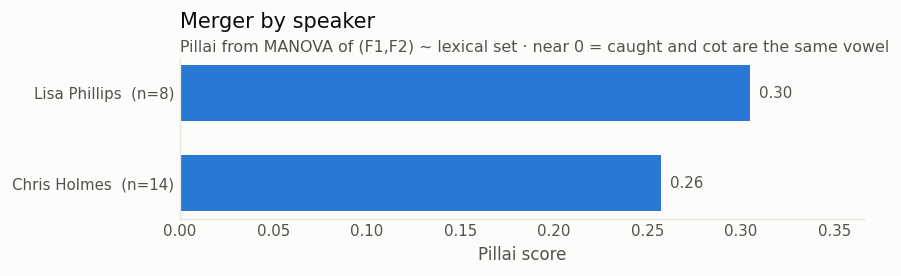

In [14]:
if len(res):
    fig, ax = plt.subplots(figsize=(7.5, max(2.4, 0.42 * len(res) + 1.2)))
    y = np.arange(len(res))
    ax.barh(y, res.pillai, color=PALETTE[0], height=0.62)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{s[:26]}  (n={n})" for s, n in zip(res.speaker, res.n)])
    ax.grid(False, axis="y")
    for i, v in enumerate(res.pillai):
        ax.annotate(f"{v:.2f}", (v, i), xytext=(5, 0), textcoords="offset points",
                    va="center", fontsize=9, color=INK_SECONDARY)
    ax.set_xlim(0, max(0.35, res.pillai.max() * 1.2))
    finish(ax, title="Merger by speaker",
           subtitle="Pillai from MANOVA of (F1,F2) ~ lexical set · "
                    "near 0 = caught and cot are the same vowel",
           xlabel="Pillai score")
    plt.show()


## 7.9 Scope and caveats

The plot is speaker-level merger status for whoever is in the subset. It is not
a dialect map: SPoRC carries no region, age, gender, or ethnicity, so there is
nothing to generalise a Pillai score to.

Limits to state in any write-up:

* **n.** A few dozen tokens per speaker is thin for a merger claim. Sociophonetic
  studies typically want 20+ tokens *per class per speaker*.
* **Formant ceiling.** `measure_formants(max_formant=5500)` is the convention for
  a female vocal tract; 5000 is the convention for male. SPoRC has no speaker
  gender, so one ceiling is applied to everyone, which biases estimates. If you
  know your speakers, pass the right ceiling.
* **Alignment precision.** Boundaries come from a CTC aligner, not hand
  correction. Good to tens of ms; fine for a midpoint measure, not for
  fine-grained duration work.
* **Channel.** Podcast audio is compressed, variously mic'd, sometimes
  music-bedded. Formant estimation assumes rather better recording conditions.
* **Speaker identity is inferred.** `inferred_speaker_name` is itself a model
  output, and ~90% of turns have no name at all (notebook 01). Tokens grouped
  under one name may not all be the same person, and `lobanov_normalize` keys on
  the name — two people sharing one pool together.
